# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 25 - 3er bimestre 2026

## **Alumno 1:** Franco Marcelo Morero

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 7 de agosto (hora de Argentina)**.

La resolución del TP debe realizarse en **parejas**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que ambos deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta. También está permitido realizar el trabajo de forma **individual** si así lo desean, aunque esta modalidad no es la más recomendable.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/dLacTc6eZMWjWGZJA)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERNOMBREALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERNOMBREALUMNO2-TP2-Co25.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP2-Co25.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

### Carga de datos e inspección inicial

Arranco cargando los dos archivos ya separados (adult_train.csv y adult_val.csv) y mirando forma, tipos y primeras filas. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [2]:
train = pd.read_csv("adult_train.csv")
val = pd.read_csv("adult_val.csv")

print(f"train: {train.shape}")
print(f"val:   {val.shape}")

train: (30162, 14)
val:   (15060, 14)


In [3]:
train.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   education       30162 non-null  object
 3   marital-status  30162 non-null  object
 4   occupation      30162 non-null  object
 5   relationship    30162 non-null  object
 6   race            30162 non-null  object
 7   sex             30162 non-null  object
 8   capital-gain    30162 non-null  int64 
 9   capital-loss    30162 non-null  int64 
 10  hours-per-week  30162 non-null  int64 
 11  skill-profile   30162 non-null  object
 12  native-country  30162 non-null  object
 13  income          30162 non-null  object
dtypes: int64(4), object(10)
memory usage: 3.2+ MB


In [5]:
nulos = pd.DataFrame({
    "n_nulos": train.isna().sum(),
    "pct_nulos": (train.isna().mean() * 100).round(2),
})
print(nulos.sort_values("n_nulos", ascending=False))

                n_nulos  pct_nulos
age                   0        0.0
workclass             0        0.0
education             0        0.0
marital-status        0        0.0
occupation            0        0.0
relationship          0        0.0
race                  0        0.0
sex                   0        0.0
capital-gain          0        0.0
capital-loss          0        0.0
hours-per-week        0        0.0
skill-profile         0        0.0
native-country        0        0.0
income                0        0.0


In [6]:
nulos_val = pd.DataFrame({
    "n_nulos": val.isna().sum(),
    "pct_nulos": (val.isna().mean() * 100).round(2),
})
print(nulos_val.sort_values("n_nulos", ascending=False))

                n_nulos  pct_nulos
age                   0        0.0
workclass             0        0.0
education             0        0.0
marital-status        0        0.0
occupation            0        0.0
relationship          0        0.0
race                  0        0.0
sex                   0        0.0
capital-gain          0        0.0
capital-loss          0        0.0
hours-per-week        0        0.0
skill-profile         0        0.0
native-country        0        0.0
income                0        0.0


In [7]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,30162.0,NaN,NaN,NaN,38.437902,13.134665,17.0,28.0,37.0,47.0,90.0
workclass,30162,7,Private,22286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,30162,16,HS-grad,9840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital-status,30162,7,Married-civ-spouse,14065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,30162,14,Prof-specialty,4038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,30162,6,Husband,12463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,30162,5,White,25933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,30162,2,Male,20380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-gain,30162.0,NaN,NaN,NaN,1092.007858,7406.346497,0.0,0.0,0.0,0.0,99999.0
capital-loss,30162.0,NaN,NaN,NaN,88.372489,404.29837,0.0,0.0,0.0,0.0,4356.0


In [8]:
train.nunique().sort_values()

sex                 2
income              2
race                5
relationship        6
workclass           7
marital-status      7
occupation         14
education          16
native-country     41
age                72
skill-profile      80
capital-loss       90
hours-per-week     94
capital-gain      118
dtype: int64

In [9]:
val.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,15060.0,NaN,NaN,NaN,38.768327,13.380676,17.0,28.0,37.0,48.0,90.0
workclass,15060,7,Private,11021,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,15060,16,HS-grad,4943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital-status,15060,7,Married-civ-spouse,6990,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,15060,14,Exec-managerial,1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,15060,6,Husband,6203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,15060,5,White,12970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,15060,2,Male,10147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-gain,15060.0,NaN,NaN,NaN,1120.301594,7703.181842,0.0,0.0,0.0,0.0,99999.0
capital-loss,15060.0,NaN,NaN,NaN,89.041899,406.283245,0.0,0.0,0.0,0.0,3770.0


In [10]:
val.nunique().sort_values()

sex                 2
income              2
race                5
relationship        6
workclass           7
marital-status      7
occupation         14
education          16
native-country     40
age                73
capital-loss       79
skill-profile      80
hours-per-week     89
capital-gain      110
dtype: int64

In [11]:
print("duplicados train:", train.duplicated().sum())
print("duplicados val:  ", val.duplicated().sum())

duplicados train: 479
duplicados val:   118


In [12]:
# filas de validación que coinciden exactamente con alguna fila de entrenamiento
en_train = val.apply(tuple, axis=1).isin(set(train.apply(tuple, axis=1)))
print(f"filas de val que aparecen en train: {en_train.sum()} ({en_train.mean():.1%} de validación)")

filas de val que aparecen en train: 405 (2.7% de validación)


In [13]:
# consistencia de categorias entre train y val, 
# para que no nos falten al crear el vocabulario de los embeddings
cat_cols = [c for c in train.select_dtypes("object").columns if c != "income"]
print("\ncategorias presentes en val y ausentes en train:")
hay = False
for c in cat_cols:
    faltan = set(val[c].unique()) - set(train[c].unique())
    if faltan:
        hay = True
        print(f"  {c}: {faltan}")
if not hay:
    print("  ninguna (val no aporta categorias nuevas)")


categorias presentes en val y ausentes en train:
  ninguna (val no aporta categorias nuevas)


### Observaciones iniciales

El dataset tiene 14 columnas y ninguna fila con nulos. Hay filas repetidas dentro de train y de validación, y además hay filas de validación que coinciden exactamente con alguna de entrenamiento. Como el dataset no trae ningún identificador individual, no puedo saber si son registros duplicados de verdad o personas distintas que comparten los mismos atributos, por eso las dejo como están.


Agrupo las variables por lo que representan:

- **Demográficas:** age, sex, race, native-country, marital-status, relationship.
- **Laborales / educativas:** workclass, occupation, education, skill-profile, hours-per-week.
- **Financieras:** capital-gain, capital-loss.
- **Objetivo:** income (binaria, <=50K / >50K).

Cuatro columnas son numéricas enteras (age, capital-gain, capital-loss, hours-per-week) y el resto son categóricas de tipo texto. 

Se puede ver que la cardinalidad varía mucho entre categóricas, teniendo desde sex con 2 valores hasta skill-profile con 80. 

El dataset de validación no contiene ninguna categoría que no esté en entrenamiento. Es bueno porque cualquier vocabulario para embeddings que arme sobre train cubre a las categorías en validación.

### Variable objetivo income

Miro la distribución de la clase en train y val. 

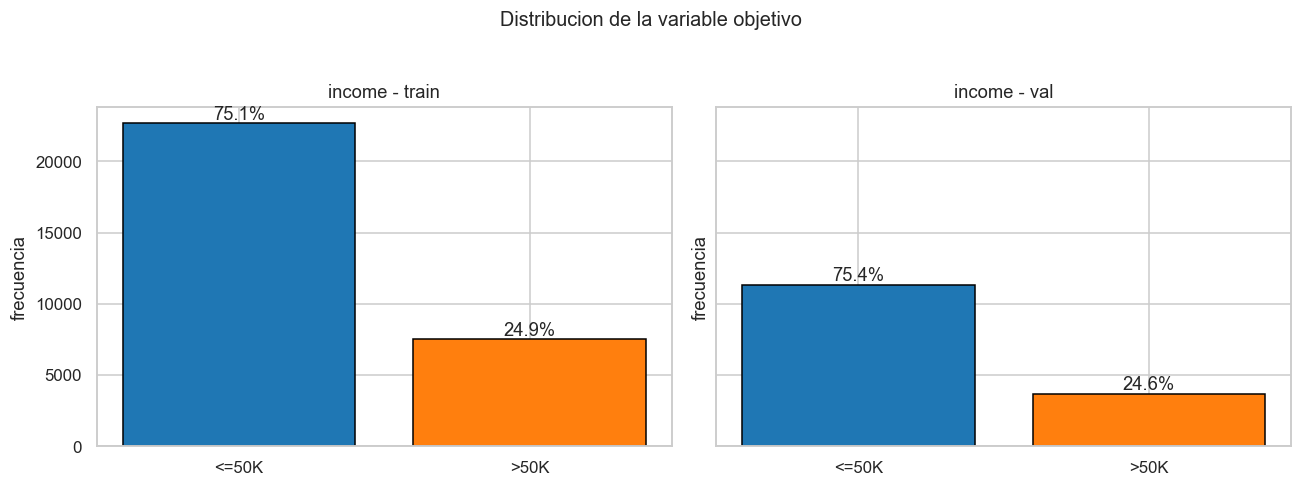

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (nombre, d) in zip(axes, [("train", train), ("val", val)]):
    vc = d["income"].value_counts()
    pct = d["income"].value_counts(normalize=True) * 100
    bars = ax.bar(vc.index, vc.values, color=["tab:blue", "tab:orange"], edgecolor="black")
    for b, p in zip(bars, pct):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{p:.1f}%", ha="center", va="bottom")
    ax.set_title(f"income - {nombre}")
    ax.set_ylabel("frecuencia")
fig.suptitle("Distribucion de la variable objetivo", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

La clase está desbalanceada, alrededor del 75% de las personas gana <=50K y solo un 25% gana >50K. La proporción es prácticamente igual en train y en val, así que la partición de los datos es correcta.

### Variables numéricas

In [15]:
num_cols = ["age", "capital-gain", "capital-loss", "hours-per-week"]

stats = pd.DataFrame({
    "media": train[num_cols].mean(),
    "mediana": train[num_cols].median(),
    "moda": [train[c].mode().iloc[0] for c in num_cols],
    "std": train[num_cols].std(),
    "min": train[num_cols].min(),
    "max": train[num_cols].max(),
}).round(2)
stats

,media,mediana,moda,std,min,max
age,38.44,37.0,36,13.13,17,90
capital-gain,1092.01,0.0,0,7406.35,0,99999
capital-loss,88.37,0.0,0,404.30,0,4356
hours-per-week,40.93,40.0,40,11.98,1,99


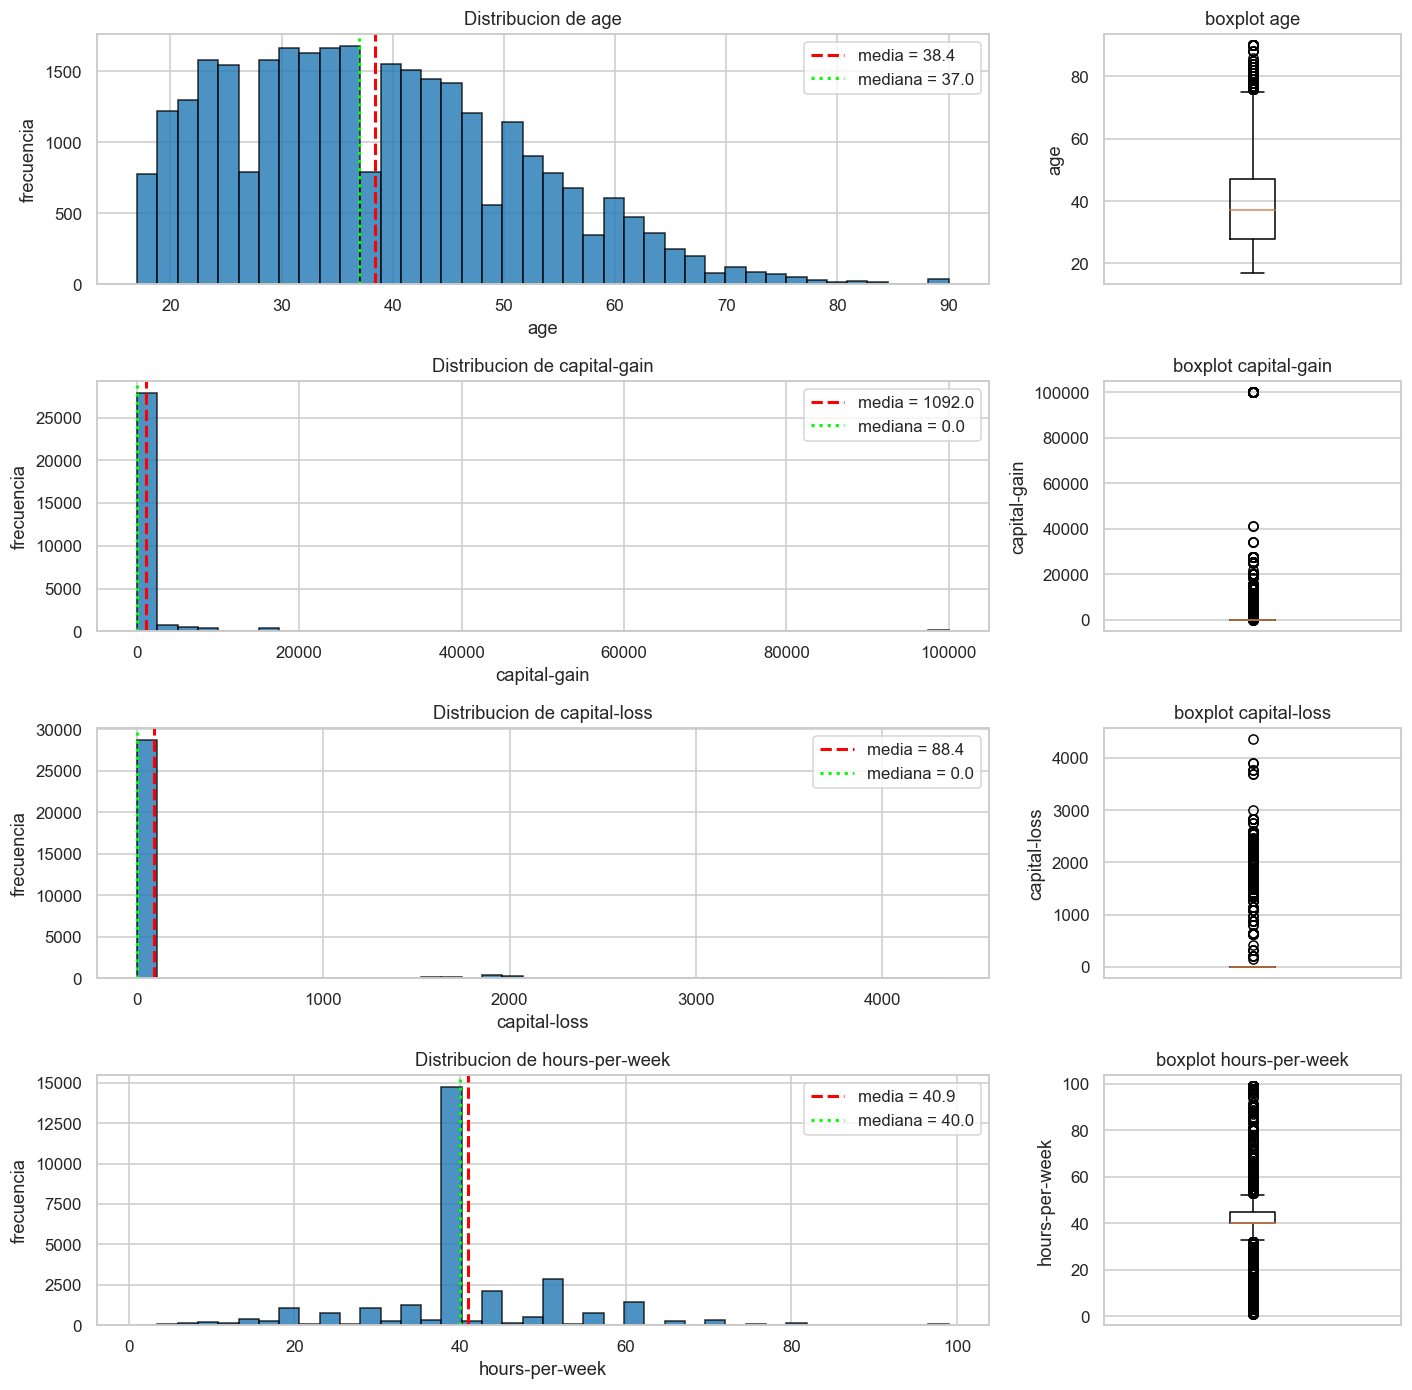

In [16]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(13, 3.2 * len(num_cols)),
                         gridspec_kw={"width_ratios": [3, 1]})
for (ax_h, ax_b), col in zip(axes, num_cols):
    s = train[col]
    ax_h.hist(s, bins=40, color="tab:blue", edgecolor="black", alpha=0.8)
    ax_h.axvline(s.mean(), color="red", ls="--", lw=2, label=f"media = {s.mean():.1f}")
    ax_h.axvline(s.median(), color="lime", ls=":", lw=2, label=f"mediana = {s.median():.1f}")
    ax_h.set_title(f"Distribucion de {col}")
    ax_h.set_xlabel(col); ax_h.set_ylabel("frecuencia"); ax_h.legend()
    ax_b.boxplot(s, vert=True)
    ax_b.set_title(f"boxplot {col}")
    ax_b.set_ylabel(col)
    ax_b.set_xticks([])
plt.tight_layout()
plt.show()

capital-gain y capital-loss están dominadas por ceros, miro cuánto pesan.

In [17]:
for col in ["capital-gain", "capital-loss"]:
    pct_cero = (train[col] == 0).mean() * 100
    sub = train.loc[train[col] > 0, col]
    print(f"{col}: {pct_cero:.1f}% en cero | no-cero -> n={len(sub)}, "
          f"mediana={sub.median():.0f}, max={sub.max()}")

capital-gain: 91.6% en cero | no-cero -> n=2538, mediana=7298, max=99999
capital-loss: 95.3% en cero | no-cero -> n=1427, mediana=1887, max=4356


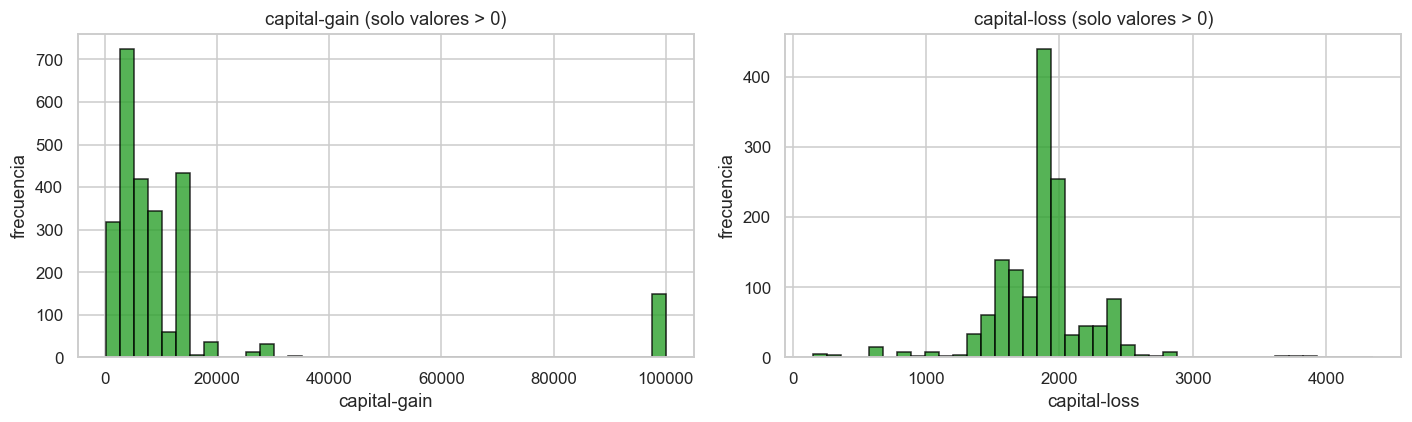

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["capital-gain", "capital-loss"]):
    sub = train.loc[train[col] > 0, col]
    ax.hist(sub, bins=40, color="tab:green", edgecolor="black", alpha=0.8)
    ax.set_title(f"{col} (solo valores > 0)")
    ax.set_xlabel(col); ax.set_ylabel("frecuencia")
plt.tight_layout()
plt.show()

Observaciones:
- age va de 17 a 90, con más gente joven y adulta que gente mayor.
- hours-per-week se concentra fuertemente en 40 (jornada completa), con colas hacia part-time y hacia jornadas muy largas.
- capital-gain y capital-loss son casi todo ceros (más del 90%).

### Numéricas frente a income

Ahora miro cada numérica separada por clase, para ver cuáles ayudan a distinguir ingresos altos de bajos.

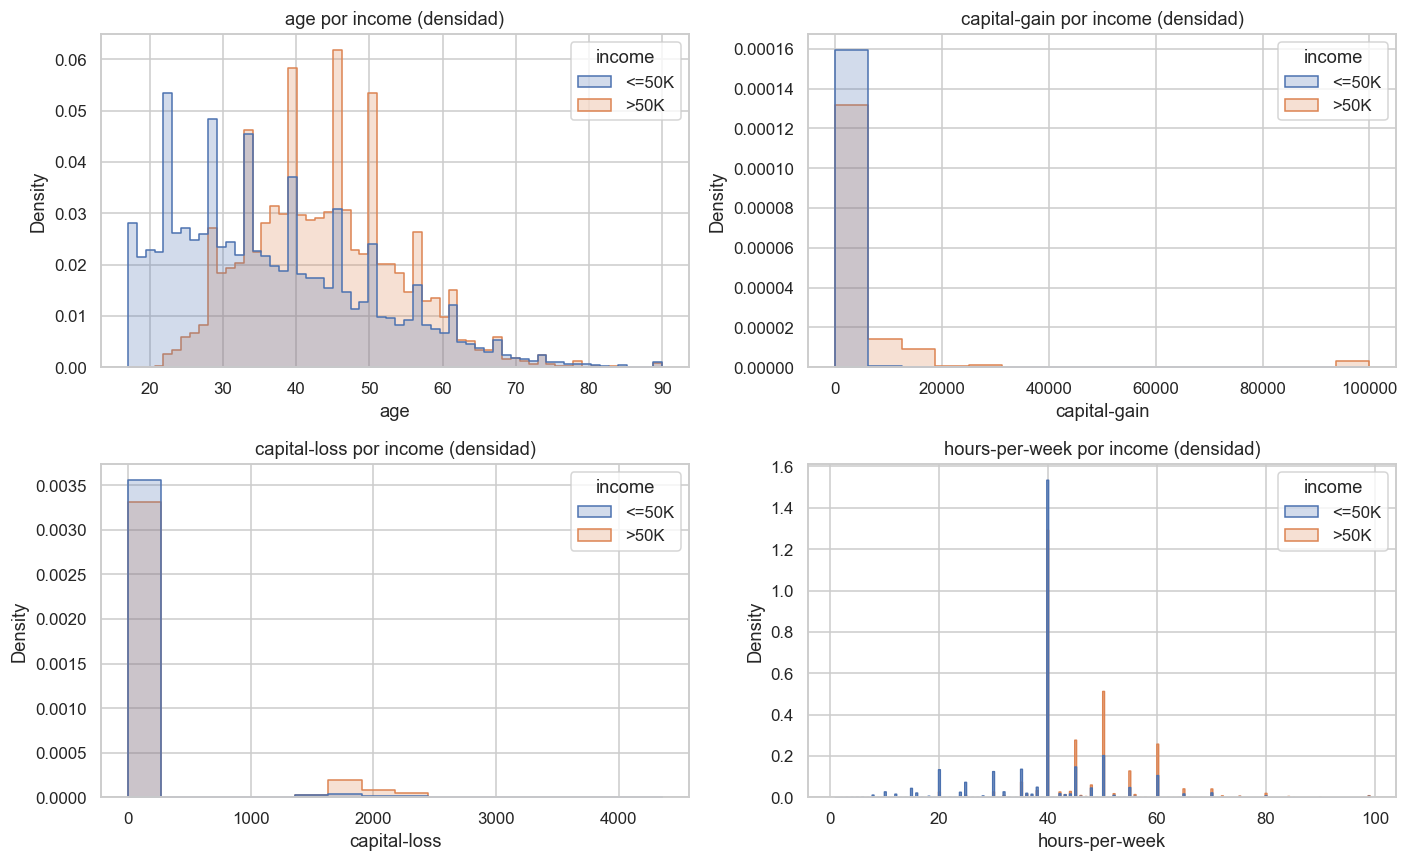

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(data=train, x=col, hue="income", stat="density",
                 common_norm=False, element="step", ax=ax)
    ax.set_title(f"{col} por income (densidad)")
plt.tight_layout()
plt.show()

Observaciones:

- La gente con >50K tiende a tener mayor edad y a trabajar más horas.
- En capital-gain casi todos los valores altos pertenecen a la clase >50K.

### Categóricas de baja cardinalidad (menos de 10 categorías únicas)

Miro frecuencias de cada categoría

In [20]:
cat_baja = ["sex", "race", "relationship", "workclass", "marital-status"]
for c in cat_baja:
    print(f"{c}: {train[c].nunique()} categorias unicas")

sex: 2 categorias unicas
race: 5 categorias unicas
relationship: 6 categorias unicas
workclass: 7 categorias unicas
marital-status: 7 categorias unicas


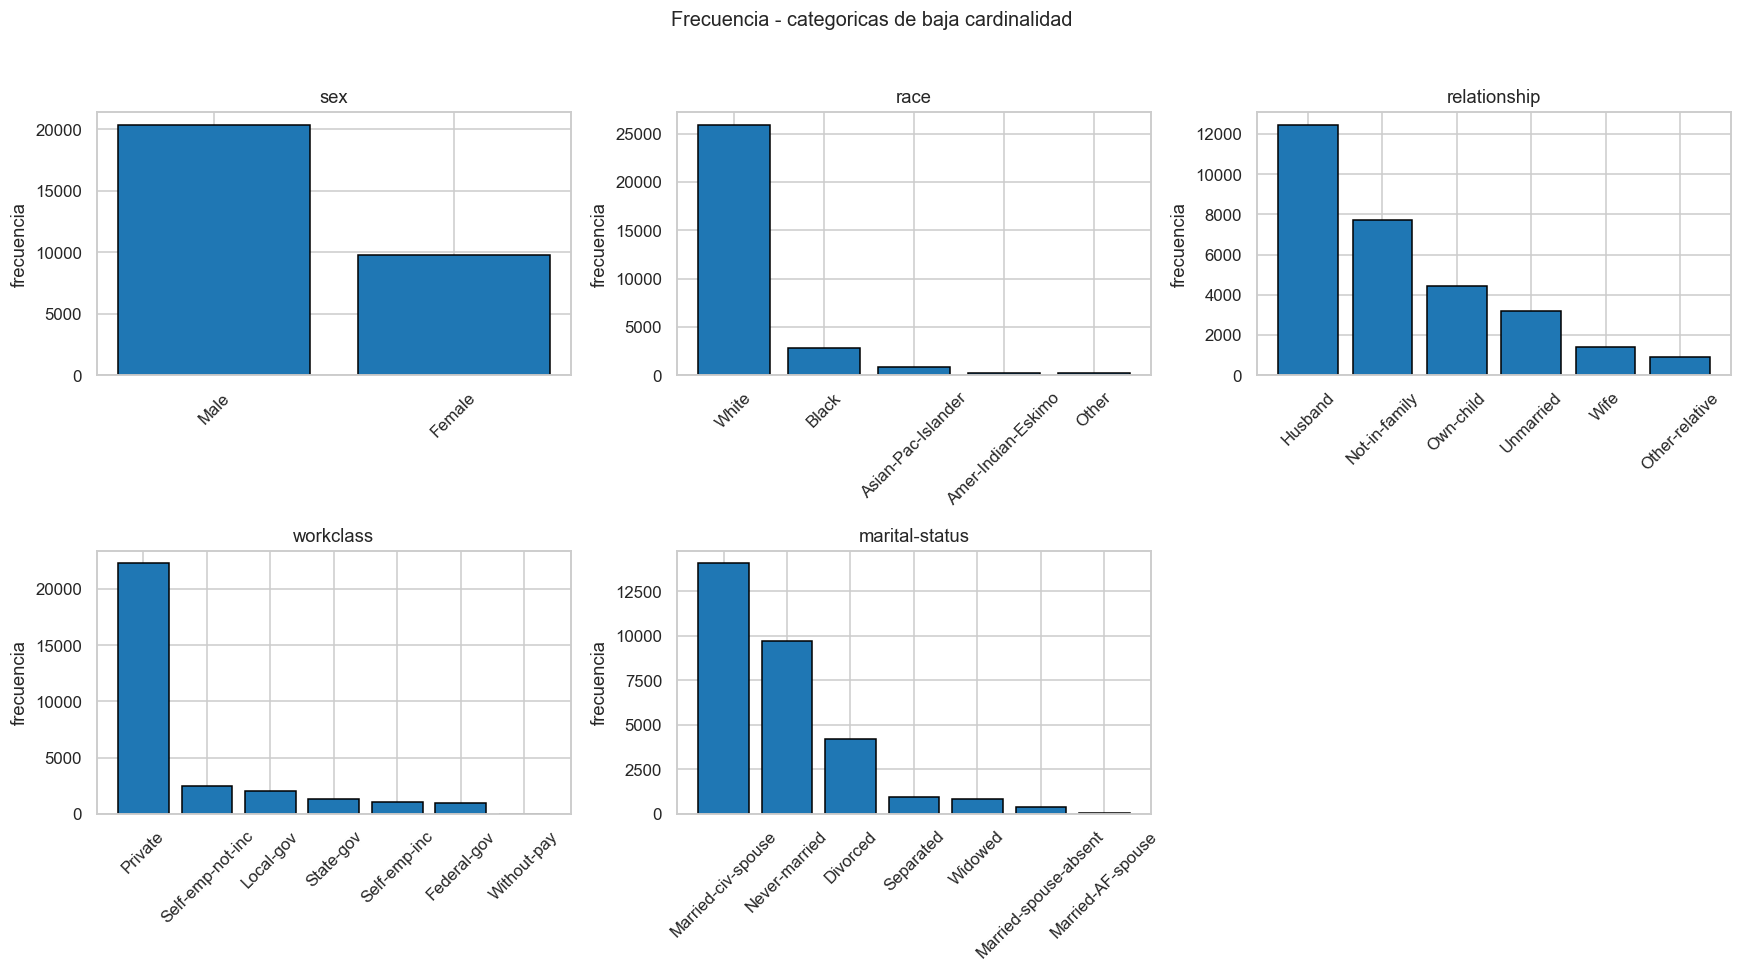

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_baja):
    vc = train[col].value_counts()
    ax.bar(vc.index, vc.values, color="tab:blue", edgecolor="black")
    ax.set_title(col); ax.set_ylabel("frecuencia")
    ax.tick_params(axis="x", rotation=45)
for ax in axes.flat[len(cat_baja):]:
    ax.axis("off")
fig.suptitle("Frecuencia - categoricas de baja cardinalidad", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Observaciones:

- sex: hay más hombres que mujeres.
- race: muy dominada por White.
- relationship: la más frecuente es Husband, seguida de Not-in-family y Own-child.
- workclass: la gran mayoría es Private.
- marital-status: se reparte sobre todo entre Married-civ-spouse y Never-married.

### Categóricas de alta cardinalidad (10 o más categorías únicas)

Miro frecuencias de cada categoría

In [22]:
cat_alta = ["occupation", "education", "native-country", "skill-profile"]
for c in cat_alta:
    print(f"{c}: {train[c].nunique()} categorias unicas")

occupation: 14 categorias unicas
education: 16 categorias unicas
native-country: 41 categorias unicas
skill-profile: 80 categorias unicas


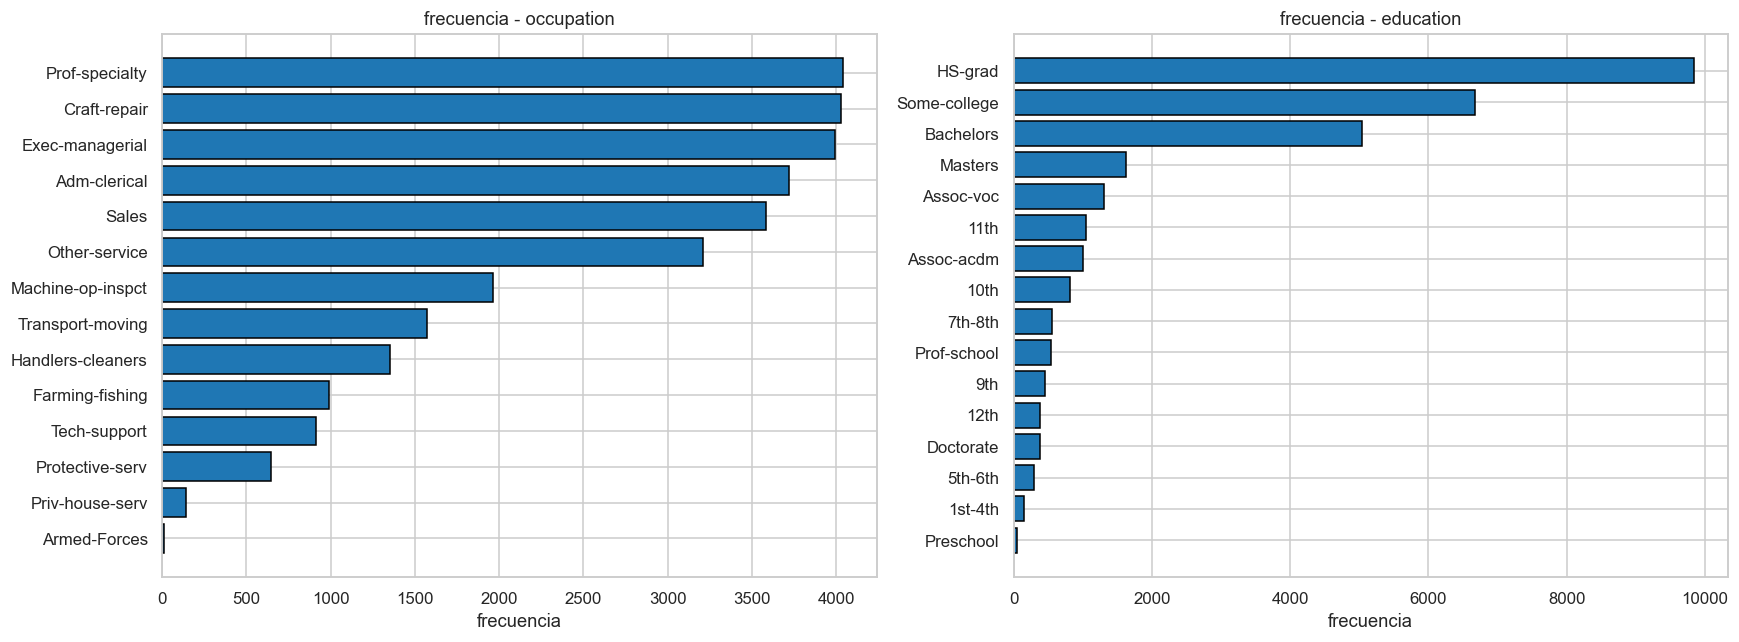

In [23]:
# occupation (14) y education (16): muestro todas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col in zip(axes, ["occupation", "education"]):
    vc = train[col].value_counts()
    ax.barh(vc.index[::-1], vc.values[::-1], color="tab:blue", edgecolor="black")
    ax.set_title(f"frecuencia - {col}")
    ax.set_xlabel("frecuencia")
plt.tight_layout()
plt.show()

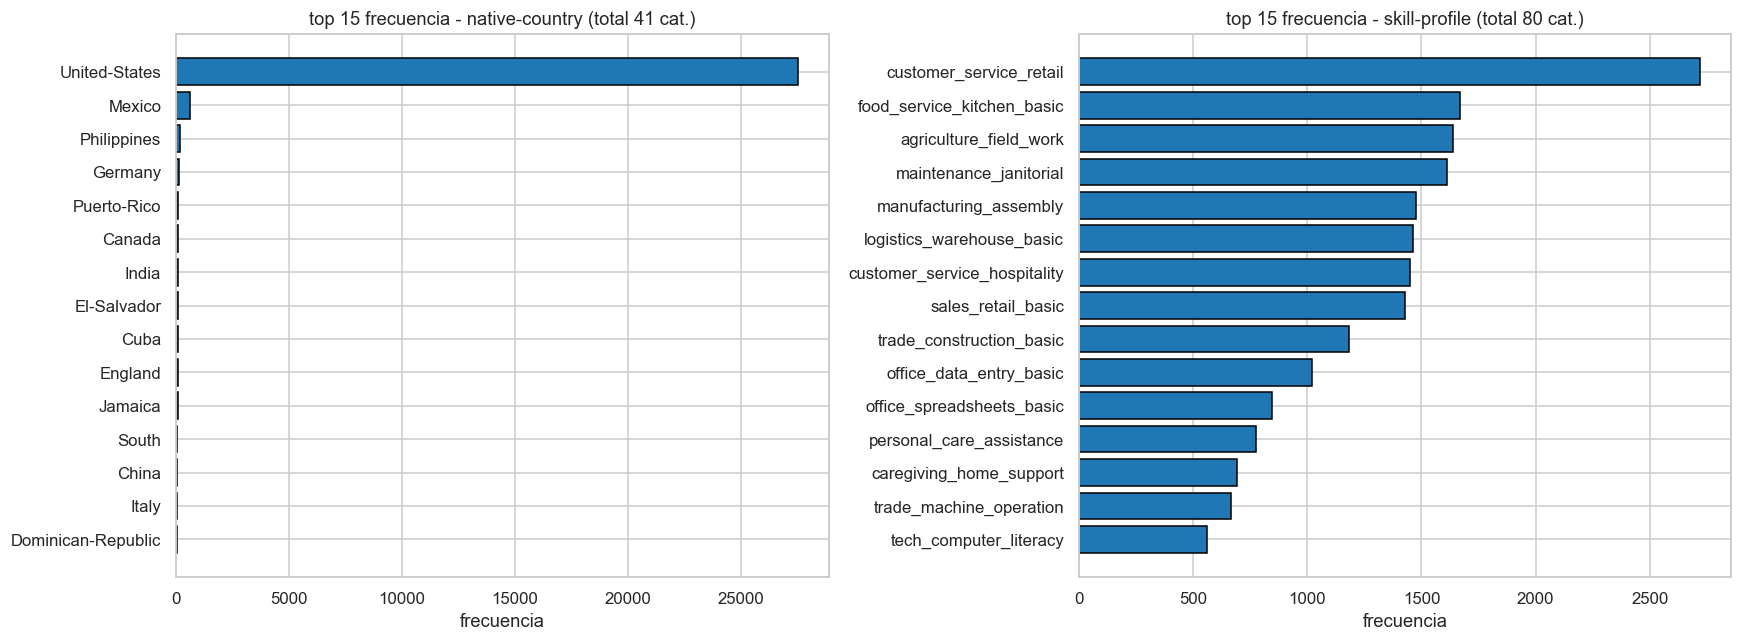

In [24]:
# native-country (41) y skill-profile (80): top 15 por frecuencia
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col in zip(axes, ["native-country", "skill-profile"]):
    vc = train[col].value_counts()
    top = vc.head(15)
    ax.barh(top.index[::-1], top.values[::-1], color="tab:blue", edgecolor="black")
    ax.set_title(f"top 15 frecuencia - {col} (total {train[col].nunique()} cat.)")
    ax.set_xlabel("frecuencia")
plt.tight_layout()
plt.show()

Observaciones:

- occupation: frecuencias repartidas, sin una categoría que domine.
- education: varias categorías con mayor frecuencia (HS-grad, Some-college, Bachelors) y otras muy chicas (Preschool, 1st-4th).
- native-country: fuertemente dominada por United-States.
- skill-profile: la frecuencia se reparte entre muchas categorías, ninguna domina de forma extrema.

### Decisión final

Con lo visto del EDA defino la transformación de cada variable:

- Numéricas (age, capital-gain, capital-loss, hours-per-week): estandarización (media 0, desvío 1).

- Categóricas de baja cardinalidad (sex, race, relationship, workclass, marital-status):
    - sex: codificación binaria 0/1. Al tener solo dos valores, una única columna alcanza y one-hot sería redundante.
    - race, relationship, workclass, marital-status: one-hot. Son pocas categorías (entre 5 y 7), así que el one-hot agrega pocas columnas y no impone un orden que no existe.

- Categóricas de alta cardinalidad (occupation, education, native-country, skill-profile):
    - occupation: embedding. Tiene 14 categorías sin orden natural. El embedding aprende una representación vectorial en lugar de sumar 14 columnas one-hot.
    - education: ordinal, de menor a mayor nivel educativo (Preschool < 1st-4th < ... < Masters < Doctorate). Tiene un orden interno claro que conviene aprovechar.
    - native-country: embedding. 41 categorías muy concentradas en un valor (United-States). El embedding evita las 41 columnas del one-hot y da representación a las categorías raras.
    - skill-profile: embedding. Misma lógica que las anteriores, pero con 80 categorías repartidas, donde el one-hot sería más costoso y disperso.
    
- Target (income): codificación binaria 0/1.

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

### Transformaciones

Implemento las transformaciones que definí al final del EDA

In [25]:
import copy
import random

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [26]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"device: {device}")

device: mps


In [27]:
# orden de education, de menor a mayor nivel educativo
orden_education = [
    "Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
    "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm",
    "Bachelors", "Masters", "Prof-school", "Doctorate",
]
mapa_education = {cat: i for i, cat in enumerate(orden_education)}

cols_onehot = ["race", "relationship", "workclass", "marital-status"]
cols_emb = ["occupation", "native-country", "skill-profile"]

# vocabularios de embeddings armados sobre train
vocabs = {c: {cat: i for i, cat in enumerate(sorted(train[c].unique()))} for c in cols_emb}
cardinalidades = [len(vocabs[c]) for c in cols_emb]

print(f"cardinalidades embeddings: {dict(zip(cols_emb, cardinalidades))}")

cardinalidades embeddings: {'occupation': 14, 'native-country': 41, 'skill-profile': 80}


In [28]:
# scaler ajustado solo en train (numericas + education ordinal)
cols_escalar = num_cols + ["education-ord"]
train_esc = train.assign(**{"education-ord": train["education"].map(mapa_education)})
scaler = StandardScaler().fit(train_esc[cols_escalar])

# columnas one-hot de referencia (las de train)
cols_dummies = pd.get_dummies(train[cols_onehot]).columns


def preparar(df):
    d = df.assign(**{"education-ord": df["education"].map(mapa_education)})
    escaladas = pd.DataFrame(scaler.transform(d[cols_escalar]), columns=cols_escalar, index=d.index)
    sexo = (d["sex"] == "Male").astype(float).rename("sex")
    dummies = pd.get_dummies(d[cols_onehot]).reindex(columns=cols_dummies, fill_value=0).astype(float)
    X_num = pd.concat([escaladas, sexo, dummies], axis=1)
    X_cat = pd.concat([d[c].map(vocabs[c]) for c in cols_emb], axis=1)
    y = (d["income"] == ">50K").astype(float)
    return (
        torch.tensor(X_num.to_numpy(), dtype=torch.float32),
        torch.tensor(X_cat.to_numpy(), dtype=torch.long),
        torch.tensor(y.to_numpy(), dtype=torch.float32),
    )

In [29]:
X_num_tr, X_cat_tr, y_tr = preparar(train)
X_num_va, X_cat_va, y_va = preparar(val)
print(f"X_num train: {tuple(X_num_tr.shape)} | X_cat train: {tuple(X_cat_tr.shape)}")
print(f"X_num val:   {tuple(X_num_va.shape)} | X_cat val:   {tuple(X_cat_va.shape)}")

X_num train: (30162, 31) | X_cat train: (30162, 3)
X_num val:   (15060, 31) | X_cat val:   (15060, 3)


### Dataset y DataLoader

Armo el Dataset y DataLoader para cada set:
- train con mini-batches de 512 y shuffle
- validación con el mismo tamaño de batch pero sin shuffle, porque ahí solo evalúo.

In [30]:
batch_size = 512

ds_train = TensorDataset(X_num_tr, X_cat_tr, y_tr)
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)

ds_val = TensorDataset(X_num_va, X_cat_va, y_va)
dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

print(f"batches por época: train {len(dl_train)} | val {len(dl_val)}")

batches por época: train 59 | val 30


### Modelo

Para las dimensiones de los embeddings uso la [heurística de fastai](https://forums.fast.ai/t/determining-dimensions-of-embeddings/55552):

- occupation (14 categorías): dimensión 7
- native-country (41): dimensión 13
- skill-profile (80): dimensión 19

In [31]:
def dim_embedding(n):
    # https://github.com/fastai/fastai/blob/96c5927648ecf83f0bc9ab601f672d3c0ffe0059/fastai/tabular/data.py#L13
    return min(600, round(1.6 * n**0.56))


dims_emb = [dim_embedding(n) for n in cardinalidades]
print(f"dimensiones de embedding: {dict(zip(cols_emb, dims_emb))}")

dimensiones de embedding: {'occupation': 7, 'native-country': 13, 'skill-profile': 19}


La red concatena los tres embeddings con el resto de las features y pasa por 2 capas ocultas de 64 y 32 neuronas con ReLU, cada una seguida de dropout 0.4.

La salida es una sola neurona sin activación. Devuelve el logit y la sigmoide queda dentro de la función de costo.

In [32]:
class ModeloEmbeddings(nn.Module):
    def __init__(self, n_features_num, cardinalidades, dims_emb, p_dropout=0.4):
        super().__init__()
        self.embeddings = nn.ModuleList(
            [nn.Embedding(n, d) for n, d in zip(cardinalidades, dims_emb)]
        )
        for emb in self.embeddings:
            nn.init.normal_(emb.weight, std=0.01)
        entrada = n_features_num + sum(dims_emb)
        self.mlp = nn.Sequential(
            nn.Linear(entrada, 64), nn.ReLU(), nn.Dropout(p_dropout),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(p_dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x_num, x_cat):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embs + [x_num], dim=1)
        return self.mlp(x).squeeze(1)

In [33]:
modelo = ModeloEmbeddings(X_num_tr.shape[1], cardinalidades, dims_emb).to(device)
print(modelo)

ModeloEmbeddings(
  (embeddings): ModuleList(
    (0): Embedding(14, 7)
    (1): Embedding(41, 13)
    (2): Embedding(80, 19)
  )
  (mlp): Sequential(
    (0): Linear(in_features=70, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [34]:
n_params = sum(p.numel() for p in modelo.parameters())
print(f"parámetros entrenables: {n_params:}")

parámetros entrenables: 8808


### Entrenamiento

Decisiones:

- Optimizador: Adam. 
- Función de costo: el problema es binario con una sola neurona de salida, así que corresponde Binary Cross Entropy. Uso [BCEWithLogitsLoss](https://docs.pytorch.org/docs/2.13/generated/torch.nn.BCEWithLogitsLoss.html), que tiene la sigmoide con la BCE dentro de la misma operación para mejor estabilidad numérica. El modelo devuelve logit y la sigmoide se aplica luego al predecir.
- Desbalance del target: la clase >50K es el 25% del train y la consigna evalúa F1 macro, así que le paso pos_weight como explica la documentación oficial de pytorch para BCEWithLogitsLoss. 
- Learning rate: fijo en 1e-3 (el default de Adam), con un scheduler [CosineAnnealingLR](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html) que lo va bajando suavemente siguiendo una curva coseno a lo largo del entrenamiento.
- Épocas: hasta un máximo de 100, con early stopping. Si el F1 macro de validación no mejora durante 10 épocas seguidas, el entrenamiento se corta y se restauran los pesos de la mejor época.

In [35]:
n_pos = (y_tr == 1).sum().item()
n_neg = (y_tr == 0).sum().item()
pos_weight = torch.tensor([n_neg / n_pos], device=device)
print(f"pos_weight: {pos_weight.item():.2f}")

pos_weight: 3.02


In [36]:
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def entrenar(modelo, lr=1e-3, epocas=100, paciencia=10, verbose=False):
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=epocas)
    hist = {k: [] for k in ["loss_train", "loss_val", "acc_train", "acc_val", "f1_train", "f1_val"]}
    mejor_f1, mejor_estado, sin_mejora = -float("inf"), None, 0
    for epoca in range(1, epocas + 1):
        modelo.train()
        for xb_num, xb_cat, yb in dl_train:
            xb_num, xb_cat, yb = xb_num.to(device), xb_cat.to(device), yb.to(device)
            loss = bce_loss(modelo(xb_num, xb_cat), yb)
            optimizador.zero_grad(set_to_none=True)
            loss.backward()
            optimizador.step()
        scheduler.step()

        loss_tr, acc_tr, f1_tr, _ = evaluar(modelo, dl_train)
        loss_va, acc_va, f1_va, _ = evaluar(modelo, dl_val)
        for k, v in zip(hist, [loss_tr, loss_va, acc_tr, acc_va, f1_tr, f1_va]):
            hist[k].append(v)
        if verbose and (epoca % 5 == 0 or epoca == 1):
            print(f"época {epoca:3d} | loss train {loss_tr:.4f} val {loss_va:.4f} | "
                  f"acc val {acc_va:.4f} | F1 macro val {f1_va:.4f}")

        if f1_va > mejor_f1:
            mejor_f1, sin_mejora = f1_va, 0
            mejor_estado = copy.deepcopy(modelo.state_dict())
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                if verbose:
                    print(f"early stopping en la época {epoca} (mejor F1 macro val: {mejor_f1:.4f})")
                break

    modelo.load_state_dict(mejor_estado)
    return hist


def evaluar(modelo, dl):
    modelo.eval()
    loss_total, y_true, y_pred = 0.0, [], []
    with torch.no_grad():
        for xb_num, xb_cat, yb in dl:
            xb_num, xb_cat, yb = xb_num.to(device), xb_cat.to(device), yb.to(device)
            logits = modelo(xb_num, xb_cat)
            loss_total += bce_loss(logits, yb).item() * len(yb)
            y_true.append(yb.cpu())
            y_pred.append((torch.sigmoid(logits) >= 0.5).float().cpu())
    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()
    return (loss_total / len(dl.dataset),
            accuracy_score(y_true, y_pred),
            f1_score(y_true, y_pred, average="macro"),
            y_pred)


def modelo_nuevo():
    torch.manual_seed(SEED)
    return ModeloEmbeddings(X_num_tr.shape[1], cardinalidades, dims_emb).to(device)

In [37]:
import time

LR = 1e-3
EPOCAS_MAX = 100
PACIENCIA = 10

inicio = time.perf_counter()
modelo = modelo_nuevo()
hist = entrenar(modelo, LR, EPOCAS_MAX, PACIENCIA, verbose=True)
tiempo_emb = time.perf_counter() - inicio
epocas_entrenadas = len(hist["loss_val"])
print(f"épocas entrenadas: {epocas_entrenadas}")
print(f"tiempo de entrenamiento: {tiempo_emb:.1f} s")

época   1 | loss train 0.5647 val 0.5629 | acc val 0.8307 | F1 macro val 0.7967
época   5 | loss train 0.4484 val 0.4551 | acc val 0.8649 | F1 macro val 0.8322
época  10 | loss train 0.4386 val 0.4508 | acc val 0.8665 | F1 macro val 0.8340
época  15 | loss train 0.4335 val 0.4500 | acc val 0.8667 | F1 macro val 0.8343
early stopping en la época 17 (mejor F1 macro val: 0.8383)
épocas entrenadas: 17
tiempo de entrenamiento: 16.9 s


### Curvas de loss, accuracy y F1 macro por época

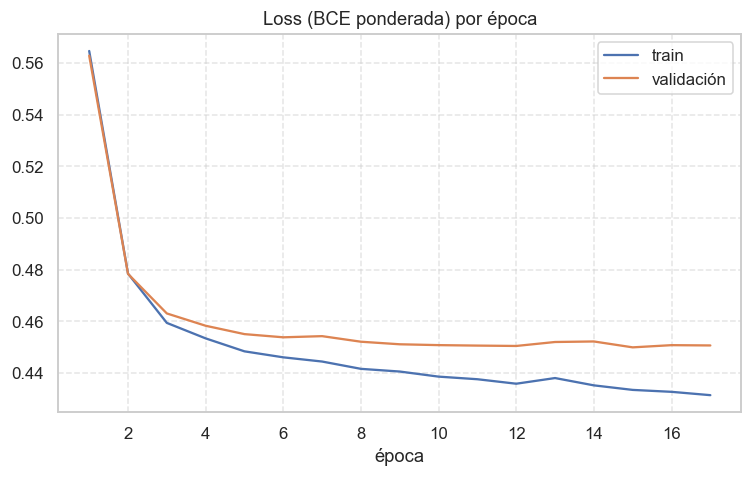

In [38]:
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, epocas_entrenadas + 1), hist["loss_train"], label="train")
plt.plot(range(1, epocas_entrenadas + 1), hist["loss_val"], label="validación")
plt.title("Loss (BCE ponderada) por época")
plt.xlabel("época")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

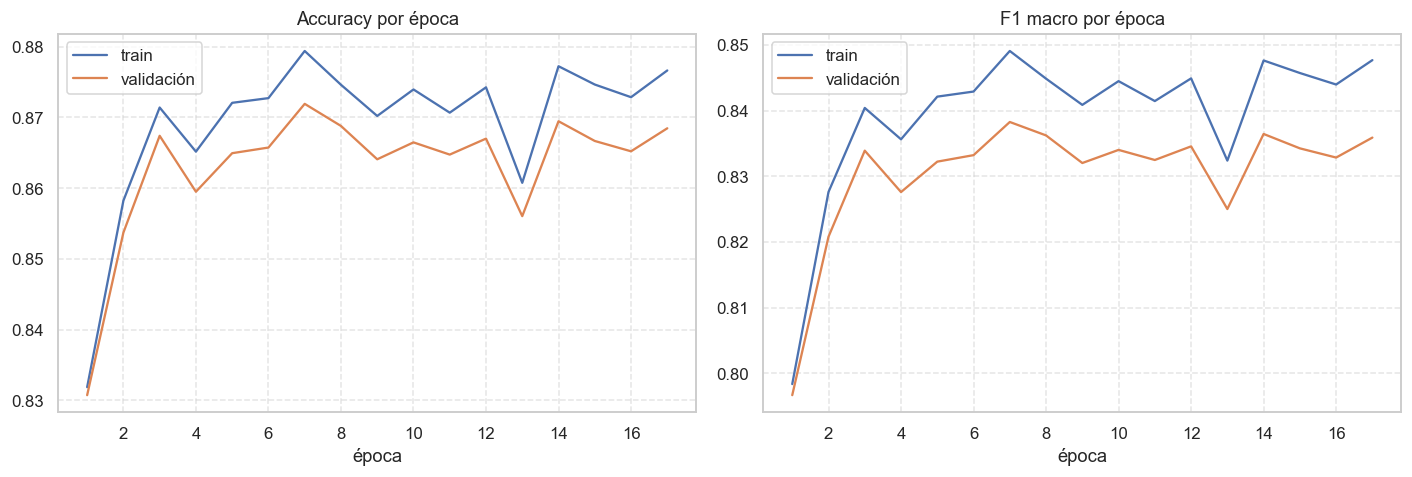

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metrica, titulo in [
    (axes[0], "acc", "Accuracy por época"),
    (axes[1], "f1", "F1 macro por época"),
]:
    ax.plot(range(1, epocas_entrenadas + 1), hist[f"{metrica}_train"], label="train")
    ax.plot(range(1, epocas_entrenadas + 1), hist[f"{metrica}_val"], label="validación")
    ax.set_title(titulo)
    ax.set_xlabel("época")
    ax.grid(True, ls="--", alpha=0.5)
    ax.legend()
plt.tight_layout()
plt.show()

La loss de validación toca piso enseguida y de ahí en más se mantiene prácticamente sin mejora, mientras la de train sigue bajando de a poco. O sea, hay un sobreajuste leve, pero no grave. La brecha entre las dos curvas se mantiene acotada, en parte por el dropout y en parte porque el modelo es chico. El early stopping corta antes de que esa brecha llegue a crecer más, y los pesos que quedan son los de la mejor época.

Las curvas de accuracy y F1 macro cuentan lo mismo desde el otro lado. Validación se estanca enseguida y después oscila alrededor de ese nivel sin caerse, y train hace lo mismo apenas más arriba, con una brecha chica y estable entre las dos. El serrucho época a época es ruido de entrenar por mini-batches, no un patrón, y de hecho las dos curvas suben y bajan juntas.

### Evaluación en validación

In [40]:
_, _, _, pred_va = evaluar(modelo, dl_val)
y_va_np = y_va.numpy()

etiquetas = ["<=50K", ">50K"]
print(classification_report(y_va_np, pred_va, target_names=etiquetas, digits=4))

              precision    recall  f1-score   support

       <=50K     0.9462    0.8803    0.9120     11360
        >50K     0.6972    0.8462    0.7645      3700

    accuracy                         0.8719     15060
   macro avg     0.8217    0.8632    0.8383     15060
weighted avg     0.8850    0.8719    0.8758     15060



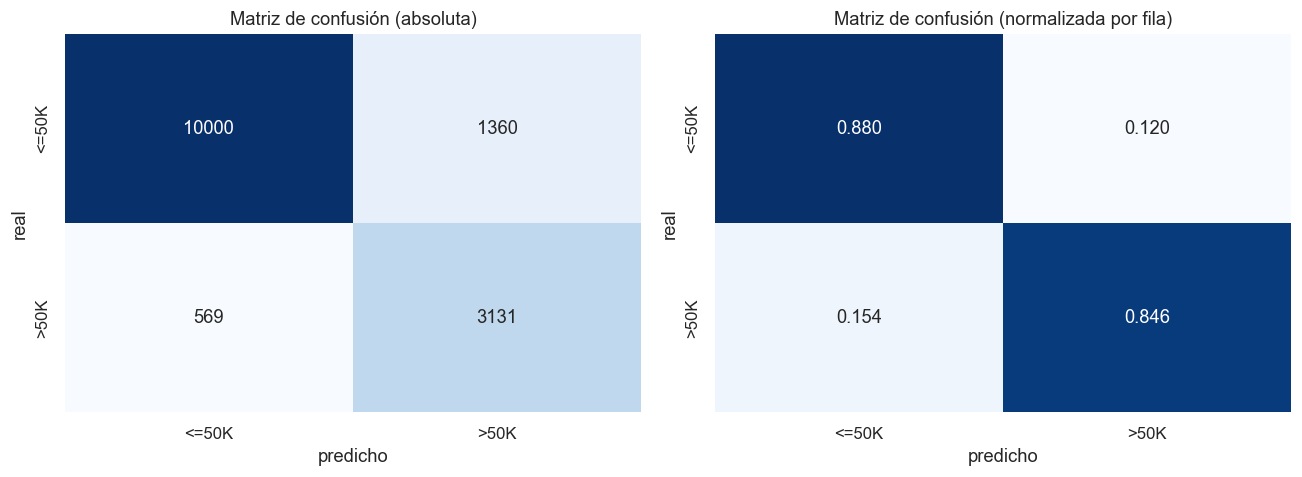

In [41]:
cm_abs = confusion_matrix(y_va_np, pred_va)
cm_norm = confusion_matrix(y_va_np, pred_va, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, cm, fmt, titulo in [
    (axes[0], cm_abs, "d", "Matriz de confusión (absoluta)"),
    (axes[1], cm_norm, ".3f", "Matriz de confusión (normalizada por fila)"),
]:
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues", cbar=False,
                xticklabels=etiquetas, yticklabels=etiquetas, ax=ax)
    ax.set_xlabel("predicho")
    ax.set_ylabel("real")
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

La matriz normalizada por fila muestra el recall de cada clase, y las dos quedan en niveles parecidos. Que la clase minoritaria alcance ese recall es consistente con el efecto esperado de pos_weight, porque sin compensar el desbalance lo esperado es un recall bastante más bajo de esa clase.

El costo de esa compensación se paga en la precisión de >50K. Como el modelo tiende a predecir más esa clase, también se la asigna a una parte de gente que en realidad gana menos, y entonces de todo lo que predice como >50K una porción no lo es. Por eso su precisión queda por debajo de la de <=50K.

Como en el TP nos interesa el F1 macro, conviene resignar algo de precisión en la clase minoritaria a cambio de una mejora en el recall, lo que sube el F1 de la clase minoritaria y así también el promedio.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

### Transformaciones

Para este segundo modelo reutilizo el pipeline anterior y hago one-hot de las tres variables que antes iban a embeddings. El resultado es una única matriz de entrada, bastante más ancha que la del modelo anterior porque cada categoría de esas tres variables ahora ocupa su propia columna.

In [42]:
# one-hot de las tres variables que antes iban a embeddings
cols_dummies_emb = pd.get_dummies(train[cols_emb]).columns


def preparar_onehot(df):
    X_num, _, y = preparar(df)
    dummies_emb = (
        pd.get_dummies(df[cols_emb])
        .reindex(columns=cols_dummies_emb, fill_value=0)
        .astype(float)
    )
    X = torch.cat([X_num, torch.tensor(dummies_emb.to_numpy(), dtype=torch.float32)], dim=1)
    return X, y


X_tr_oh, y_tr_oh = preparar_onehot(train)
X_va_oh, y_va_oh = preparar_onehot(val)
print(f"X train: {tuple(X_tr_oh.shape)} | X val: {tuple(X_va_oh.shape)}")


X train: (30162, 166) | X val: (15060, 166)


### Dataset y DataLoader

Armo los DataLoader con el mismo tamaño de batch que en el modelo anterior, así los tiempos de entrenamiento son comparables.

In [43]:
batch_size = 512

ds_train_oh = TensorDataset(X_tr_oh, y_tr_oh)
ds_val_oh = TensorDataset(X_va_oh, y_va_oh)
dl_train_oh = DataLoader(ds_train_oh, batch_size=batch_size, shuffle=True)
dl_val_oh = DataLoader(ds_val_oh, batch_size=batch_size)

print(f"batches por época: train {len(dl_train_oh)} | val {len(dl_val_oh)}")

batches por época: train 59 | val 30


### Modelo sin embeddings

Misma arquitectura del modelo anterior, pero sin dropout y con la primera capa lineal con más entradas por el one-hot. 

In [44]:
class ModeloOneHot(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.mlp(x).squeeze(1)


def modelo_nuevo_oh():
    torch.manual_seed(SEED)
    return ModeloOneHot(X_tr_oh.shape[1]).to(device)


modelo_oh = modelo_nuevo_oh()
print(modelo_oh)
n_params_oh = sum(p.numel() for p in modelo_oh.parameters())
print(f"parámetros entrenables: {n_params_oh}")


ModeloOneHot(
  (mlp): Sequential(
    (0): Linear(in_features=166, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
parámetros entrenables: 12801


### Entrenamiento

Utilizo los mismos hiperparámetros, función de costo, optimizador y scheduler que en el modelo anterior para que los resultados sean comparables.

In [45]:
def evaluar_oh(modelo, dl):
    modelo.eval()
    loss_total, y_true, y_pred = 0.0, [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = modelo(xb)
            loss_total += bce_loss(logits, yb).item() * len(yb)
            y_true.append(yb.cpu())
            y_pred.append((torch.sigmoid(logits) >= 0.5).float().cpu())
    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()
    return (loss_total / len(dl.dataset),
            accuracy_score(y_true, y_pred),
            f1_score(y_true, y_pred, average="macro"),
            y_pred)


def entrenar_oh(modelo, lr=1e-3, epocas=100, paciencia=10, verbose=False):
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=epocas)
    hist = {k: [] for k in ["loss_train", "loss_val", "acc_train", "acc_val", "f1_train", "f1_val"]}
    mejor_f1, mejor_estado, sin_mejora = -float("inf"), None, 0
    for epoca in range(1, epocas + 1):
        modelo.train()
        for xb, yb in dl_train_oh:
            xb, yb = xb.to(device), yb.to(device)
            loss = bce_loss(modelo(xb), yb)
            optimizador.zero_grad(set_to_none=True)
            loss.backward()
            optimizador.step()
        scheduler.step()

        loss_tr, acc_tr, f1_tr, _ = evaluar_oh(modelo, dl_train_oh)
        loss_va, acc_va, f1_va, _ = evaluar_oh(modelo, dl_val_oh)
        for k, v in zip(hist, [loss_tr, loss_va, acc_tr, acc_va, f1_tr, f1_va]):
            hist[k].append(v)
        if verbose and (epoca % 5 == 0 or epoca == 1):
            print(f"época {epoca:3d} | loss train {loss_tr:.4f} val {loss_va:.4f} | "
                  f"acc val {acc_va:.4f} | F1 macro val {f1_va:.4f}")

        if f1_va > mejor_f1:
            mejor_f1, sin_mejora = f1_va, 0
            mejor_estado = copy.deepcopy(modelo.state_dict())
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                if verbose:
                    print(f"early stopping en la época {epoca} (mejor F1 macro val: {mejor_f1:.4f})")
                break

    modelo.load_state_dict(mejor_estado)
    return hist

In [46]:
inicio = time.perf_counter()
modelo_oh = modelo_nuevo_oh()
hist_oh = entrenar_oh(modelo_oh, LR, EPOCAS_MAX, PACIENCIA, verbose=True)
tiempo_oh = time.perf_counter() - inicio
epocas_entrenadas_oh = len(hist_oh["loss_val"])
print(f"épocas entrenadas: {epocas_entrenadas_oh}")
print(f"tiempo de entrenamiento: {tiempo_oh:.1f} s")

época   1 | loss train 0.5714 val 0.5700 | acc val 0.8228 | F1 macro val 0.7894
época   5 | loss train 0.4407 val 0.4507 | acc val 0.8623 | F1 macro val 0.8299
época  10 | loss train 0.4265 val 0.4519 | acc val 0.8710 | F1 macro val 0.8377
época  15 | loss train 0.4178 val 0.4546 | acc val 0.8674 | F1 macro val 0.8346
época  20 | loss train 0.4101 val 0.4573 | acc val 0.8653 | F1 macro val 0.8329
early stopping en la época 24 (mejor F1 macro val: 0.8388)
épocas entrenadas: 24
tiempo de entrenamiento: 14.2 s


### Curvas de loss, accuracy y F1 macro por época

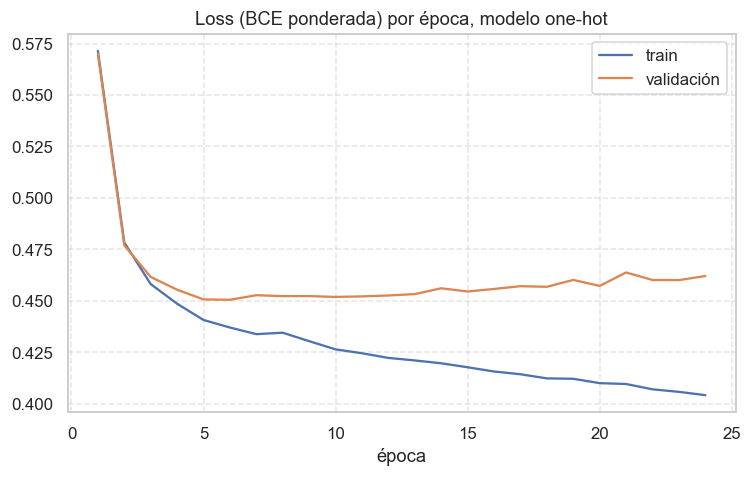

In [47]:
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, epocas_entrenadas_oh + 1), hist_oh["loss_train"], label="train")
plt.plot(range(1, epocas_entrenadas_oh + 1), hist_oh["loss_val"], label="validación")
plt.title("Loss (BCE ponderada) por época, modelo one-hot")
plt.xlabel("época")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


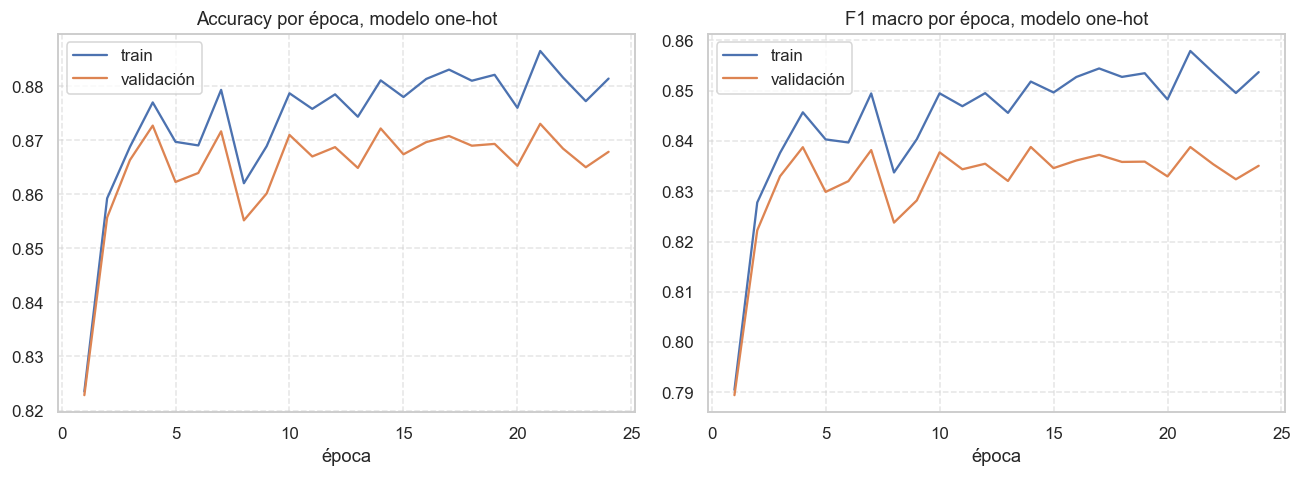

In [48]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
ejes[0].plot(range(1, epocas_entrenadas_oh + 1), hist_oh["acc_train"], label="train")
ejes[0].plot(range(1, epocas_entrenadas_oh + 1), hist_oh["acc_val"], label="validación")
ejes[0].set_title("Accuracy por época, modelo one-hot")
ejes[0].set_xlabel("época")
ejes[0].grid(True, ls="--", alpha=0.5)
ejes[0].legend()
ejes[1].plot(range(1, epocas_entrenadas_oh + 1), hist_oh["f1_train"], label="train")
ejes[1].plot(range(1, epocas_entrenadas_oh + 1), hist_oh["f1_val"], label="validación")
ejes[1].set_title("F1 macro por época, modelo one-hot")
ejes[1].set_xlabel("época")
ejes[1].grid(True, ls="--", alpha=0.5)
ejes[1].legend()
plt.tight_layout()
plt.show()


Acá el early stopping corta más tarde que en el modelo con embeddings. Sin dropout el sobreajuste se nota un poco más. La loss de train sigue bajando durante todo el entrenamiento mientras la de validación se aplana temprano y sobre el final sube de a poco, con una brecha entre curvas algo más ancha que antes. En accuracy y F1 macro pasa lo mismo desde el otro lado, validación se estanca y oscila alrededor de su nivel mientras train sigue mejorando. 

### Evaluación en validación

In [49]:
_, _, _, pred_va_oh = evaluar_oh(modelo_oh, dl_val_oh)
print(classification_report(y_va_np, pred_va_oh, target_names=etiquetas, digits=4))


              precision    recall  f1-score   support

       <=50K     0.9470    0.8798    0.9122     11360
        >50K     0.6969    0.8489    0.7654      3700

    accuracy                         0.8722     15060
   macro avg     0.8220    0.8643    0.8388     15060
weighted avg     0.8856    0.8722    0.8761     15060



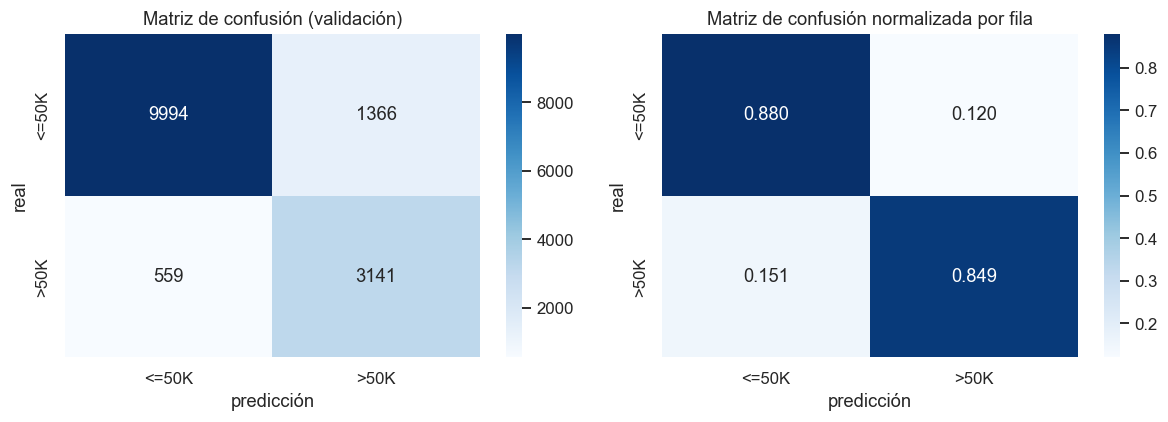

In [50]:
cm_oh = confusion_matrix(y_va_np, pred_va_oh)
cm_oh_norm = confusion_matrix(y_va_np, pred_va_oh, normalize="true")

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm_oh, annot=True, fmt="d", cmap="Blues",
            xticklabels=etiquetas, yticklabels=etiquetas, ax=ejes[0])
ejes[0].set_title("Matriz de confusión (validación)")
ejes[0].set_xlabel("predicción")
ejes[0].set_ylabel("real")
sns.heatmap(cm_oh_norm, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=etiquetas, yticklabels=etiquetas, ax=ejes[1])
ejes[1].set_title("Matriz de confusión normalizada por fila")
ejes[1].set_xlabel("predicción")
ejes[1].set_ylabel("real")
plt.tight_layout()
plt.show()


Los números finales quedan casi iguales a los del modelo con embeddings, misma accuracy a efectos prácticos, mismo F1 macro y el mismo patrón por clase. Las matrices son similares a las del modelo anterior, con recall parejo entre clases y la mayor parte del error en gente de <=50K que el modelo marca como >50K, que es el costo de compensar el desbalance con pos_weight y explica la precisión más baja de esa clase. No se observa un cambio relevante en el patrón global de errores respecto del modelo con embeddings. Para este dataset, cambiar la representación de entrada no mueve las métricas.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.

Antes de armar la tabla mido el tiempo de predicción de cada modelo sobre el set de validación completo.

In [51]:
def sincronizar():
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()


def benchmark_prediccion(fn, repeticiones):
    fn()
    sincronizar()
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        fn()
        sincronizar()
        tiempos.append(time.perf_counter() - inicio)
    return np.median(tiempos), np.std(tiempos)

In [52]:
X_num_va_d, X_cat_va_d = X_num_va.to(device), X_cat_va.to(device)
X_va_oh_d = X_va_oh.to(device)

repeticiones = 100

modelo.eval()
modelo_oh.eval()
with torch.no_grad():
    t_pred_emb, t_std_emb = benchmark_prediccion(lambda: torch.sigmoid(modelo(X_num_va_d, X_cat_va_d)), repeticiones=repeticiones)
    t_pred_oh, t_std_oh = benchmark_prediccion(lambda: torch.sigmoid(modelo_oh(X_va_oh_d)), repeticiones=repeticiones)

print(f"predicción sobre validación completa: embeddings {t_pred_emb * 1000:.2f} ± {t_std_emb * 1000:.2f} ms | one-hot {t_pred_oh * 1000:.2f} ± {t_std_oh * 1000:.2f} ms")

predicción sobre validación completa: embeddings 1.76 ± 0.14 ms | one-hot 0.82 ± 0.14 ms


También mido el tamaño en MB de los modelos.

In [53]:
import io

def tamano_mb(modelo):
    buffer = io.BytesIO()
    torch.save(modelo.state_dict(), buffer)
    return buffer.getbuffer().nbytes / 1024**2

tamano_emb = tamano_mb(modelo)
tamano_oh = tamano_mb(modelo_oh)
print(f"tamaño del modelo: embeddings {tamano_emb:.2f} MB | one-hot {tamano_oh:.2f} MB")

tamaño del modelo: embeddings 0.04 MB | one-hot 0.05 MB


In [54]:
_, acc_emb, f1_emb, _ = evaluar(modelo, dl_val)
_, acc_oh, f1_oh, _ = evaluar_oh(modelo_oh, dl_val_oh)

tabla = pd.DataFrame(
    {
        "con embeddings": [
            X_num_tr.shape[1] + len(cols_emb),
            X_num_tr.shape[1] + sum(dims_emb),
            n_params,
            f"{tamano_emb:.3f}",
            epocas_entrenadas,
            f"{acc_emb:.4f}",
            f"{f1_emb:.4f}",
            f"{tiempo_emb:.1f}",
            f"{t_pred_emb * 1000:.2f}",
        ],
        "one-hot": [
            X_tr_oh.shape[1],
            X_tr_oh.shape[1],
            n_params_oh,
            f"{tamano_oh:.3f}",
            epocas_entrenadas_oh,
            f"{acc_oh:.4f}",
            f"{f1_oh:.4f}",
            f"{tiempo_oh:.1f}",
            f"{t_pred_oh * 1000:.2f}",
        ],
    },
    index=[
        "columnas de entrada",
        "entradas al MLP",
        "parámetros entrenables",
        "tamaño guardado (MB)",
        "épocas entrenadas",
        "accuracy (validación)",
        "F1 macro (validación)",
        "tiempo de entrenamiento (s)",
        "predicción sobre validación (ms)",
    ],
)
tabla


,con embeddings,one-hot
columnas de entrada,34,166
entradas al MLP,70,166
parámetros entrenables,8808,12801
tamaño guardado (MB),0.037,0.051
épocas entrenadas,17,24
accuracy (validación),0.8719,0.8722
F1 macro (validación),0.8383,0.8388
tiempo de entrenamiento (s),16.9,14.2
predicción sobre validación (ms),1.76,0.82


De la tabla y de todo lo anterior saco estas observaciones.

- En métricas los dos modelos empatan. La accuracy y el F1 macro de validación difieren muy poco, y el classification report y las matrices de confusión muestran el mismo patrón de errores. Para este dataset usar embedding o one-hot para la representación de la entrada no cambia lo que el modelo aprende.

- En tamaño gana el de embeddings. El one-hot expande cada categoría en una columna, esa anchura extra cae toda sobre la primera capa lineal y el modelo termina más pesado, tanto en parámetros como en disco. Los embeddings comprimen cada categoría en un vector de pocas dimensiones y eso mantiene chica la red.

- En velocidad, en esta ejecución y sobre el hardware usado, el one-hot mostró un forward más rápido y entrenó en menos tiempo aun corriendo más épocas. Su forward es una sola cadena de multiplicaciones de matrices, mientras que el de embeddings hace lookups y concatena antes de entrar al MLP, operaciones chicas que suman overhead. Es un efecto por la escala, con miles de categorías la primera capa del one-hot crecería tanto que la cuenta seguramente se daría vuelta.

- La falta de dropout se nota, aunque poco. La brecha entre train y validación del one-hot es algo más ancha y su loss de validación llega a subir sobre el final.

Mi conclusión es que en lo predictivo los dos enfoques rinden igual en este caso de uso, así que la elección de un modelo u otro pasa por todo lo demás. El one-hot es más simple y acá hasta más rápido, pero escala mal porque cada categoría nueva agrega una nueva columna y más parámetros a la red. Los embeddings mantienen la entrada compacta, escalan con la dimensión elegida en lugar de con la cardinalidad, y además aprenden una representación donde categorías parecidas quedan cerca. Con los datos que se manejan en el TP ambos son viables, pero con catálogos grandes (usuarios, productos, etc.) los embeddings son la opción a elegir.